# **pyNamo-EGT tutorial**

This notebook introduces the main pyNamo-EGT workflow: define a game, plot its replicator-dynamics phase portrait, inspect equilibria, and customize publication-quality figures.

The package focuses on games where the state space can be visualized directly.

## 1. Setup and interactive widget

Import pyNamo as `pn`. Ordinary figures use high-resolution inline PNG previews (Retina PNGs) for sharp, more reliable display in Binder. The explorer and 3D examples enable the widget backend for interaction and rotation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pynamo_egt as pn

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

The widget is useful for quick exploration of the built-in examples. The default settings are chosen to work reasonably well across different examples, but no single set of visual parameters is optimal for every game. For teaching or publication figures, users will often want to adjust trajectory starting points, integration time, colors, arrows, vector fields, speed fields, or the 3D viewing angle.

Some examples may emit warnings; these are discussed in the sections on stability classification and degenerate equilibrium sets.

In [2]:
%matplotlib widget

plt.close("all")
pn.interactive.launch_replicator_widget()

**Binder note**: Interactive 3D plots may occasionally appear blank in Binder. Try rerunning the plotting cell. If the issue persists, replace %matplotlib widget with %matplotlib inline to display a static figure without rotation. SVG/PDF export quality is unaffected.

## 2. Mathematical model

For a game with state vector $x$, pyNamo studies the replicator vector field

$$
\dot{x} = F(x).
$$

For a symmetric one-population game with payoff matrix $A$, the replicator equation is

$$
\dot{x}_i = x_i \left((Ax)_i - x^\top A x\right).
$$

The state remains in the simplex

$$
\Delta = \left\{x \in \mathbb{R}^n : x_i \ge 0, \sum_i x_i = 1\right\}.
$$

For asymmetric games, pyNamo uses one replicator equation per player/population. The payoff to each pure strategy is computed against the current mixed strategies of the other players. To keep this tutorial focused on usage, we do not introduce the full multi-index notation here; see standard references on multi-population replicator dynamics for the formal definition.

### Supported game classes


Class names describe **populations**, not the number of players in an interaction:

| Class | Populations and strategies | State space |
|---|---|---|
| `1Pop2S` | One population, two strategies | Line |
| `1Pop3S` | One population, three strategies | Triangle |
| `1Pop4S` | One population, four strategies | Tetrahedron |
| `2Pop2S` | Two populations, two strategies each | Square |
| `3Pop2S` | Three populations, two strategies each | Cube |


## 3. Quick example: a three-strategy portrait

The built-in `coordination_123` game has three strategies, so its population states form a triangle. Pass that game to `pn.phase_portrait` to draw its trajectories and equilibria. The same plotting function chooses the appropriate state space from the game supplied to it.

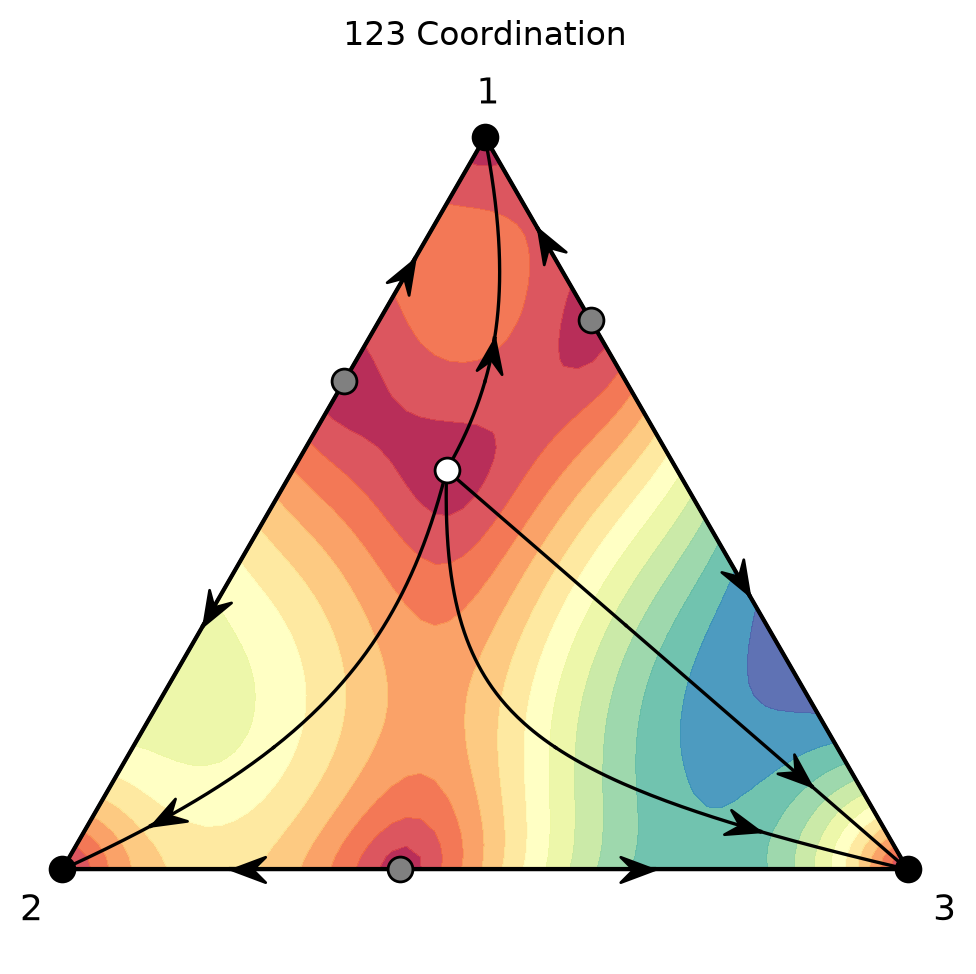

In [3]:
%matplotlib inline
plt.close("all")

fig, ax = pn.phase_portrait(game=pn.examples.games.coordination_123)
plt.show()

`pn.phase_portrait` returns two standard Matplotlib objects:

```python
fig, ax = pn.phase_portrait(...)
```

pyNamo relies on Matplotlib for plotting. This means that figures created by pyNamo can be customized, modified, and saved using ordinary Matplotlib commands.

`fig` is the full figure. You use it when you want to save the figure or adjust figure-level settings.

`ax` is the axes object containing the phase portrait. You use it when you want to modify the plot itself, for example by changing the title, adding annotations, or drawing extra lines.

For example:

```python
fig.savefig("coordination_123.svg", bbox_inches="tight")
ax.set_title("My custom title")
```

Users who want finer control over the final appearance of figures can use the standard Matplotlib documentation as a reference.

## 4. pyNamo's game catalog

In the above three-strategy example, you may have noticed that the game we have used is defined using `pn.examples.games.coordination_123`. It comes from the built-in examples of the package.

Indeed, we have defined a small list of example games that live in `pn.examples.games`. You can access them by attribute, by name, or by game class.

In [4]:
pn.examples.games.names()

['good_rps',
 'hawk_dove_retaliator',
 'standard_rps',
 'coordination_123',
 'pure_coordination',
 'repeated_pd_tft_allc_alld',
 'matching_pennies',
 'prisoners_dilemma',
 'hawk_dove',
 'coordination_game',
 'mutualism_game',
 'two_population_hawk_dove',
 'battle_of_the_sexes',
 'stag_hunt',
 'rps_with_twin',
 'rps_with_plasticity',
 'chaotic_four_strategy_game',
 'ownership_game',
 'coordination_cube',
 'cyclic_mismatching_pennies',
 'cyclic_matching_pennies']

In [5]:
g = pn.examples.games.standard_rps

g.describe()

# Equivalent lookup:
# pn.examples.games(name="battle_of_the_sexes")
# pn.examples.games.by_class(game_class="2Pop2S")

Standard RPS
------------
Game class: 1Pop3S
Symmetric: True

Description:
Standard zero-sum Rock-Paper-Scissors.

Illustrates:
Closed orbits/center-like behavior under the replicator dynamic.

Parameters:
win value w = 1, loss cost l = 1.

Reference:
Sandholm (2010), Example 3.3.2 and Example 6.1.1.

Reference note:
Standard RPS is the case w = l.

Strategy labels:
['R', 'P', 'S']

Player strategy labels:
[['R', 'P', 'S']]

Player labels:
['Population']

Payoff data:
[[ 0. -1.  1.]
 [ 1.  0. -1.]
 [-1.  1.  0.]]


## 5. Constructing and exploring games

In pyNamo, games are represented by `pn.Game` objects. A `Game` stores the payoff data, player and strategy labels, inferred game class, and optional metadata used by plotting, analysis, and examples. We assign each game to a variable such as `g`, which we then pass to plotting and analysis functions.

The examples below show how to construct games with different state spaces and explore their dynamics.

Useful attributes include:

```python
g.name
g.payoff_data
g.game_class
g.strategy_labels
g.player_strategy_labels
g.player_labels
```

Some useful methods include:
```python
g.describe()
```



### 1-population, 2-strategy game

Consider a population in which individuals use one of two strategies, $A$ or $B$. A single $2\times2$ payoff matrix gives the payoff to the strategy in each row against the strategy in each column. pyNamo uses the replicator dynamic to show how the strategy frequencies change over time.

The state variable $x$ is the frequency of the **first** strategy, $A$. Thus $x=0$ means everyone uses $B$, and $x=1$ means everyone uses $A$. The phase portrait is a line from the all-$B$ state on the left to the all-$A$ state on the right. Arrows show whether $x$ increases or decreases; circles mark frequencies at which it does not change. By default, black-filled circles mark attracting equilibria, and white-filled circles mark repelling equilibria. You can change their fill colors with sink_color and source_color, respectively.

The example below is a coordination game: each strategy does better when it is sufficiently common. Read the payoff matrix first, then use the arrows to see which initial frequencies lead to all $A$ or all $B$. The middle equilibrium separates those outcomes.


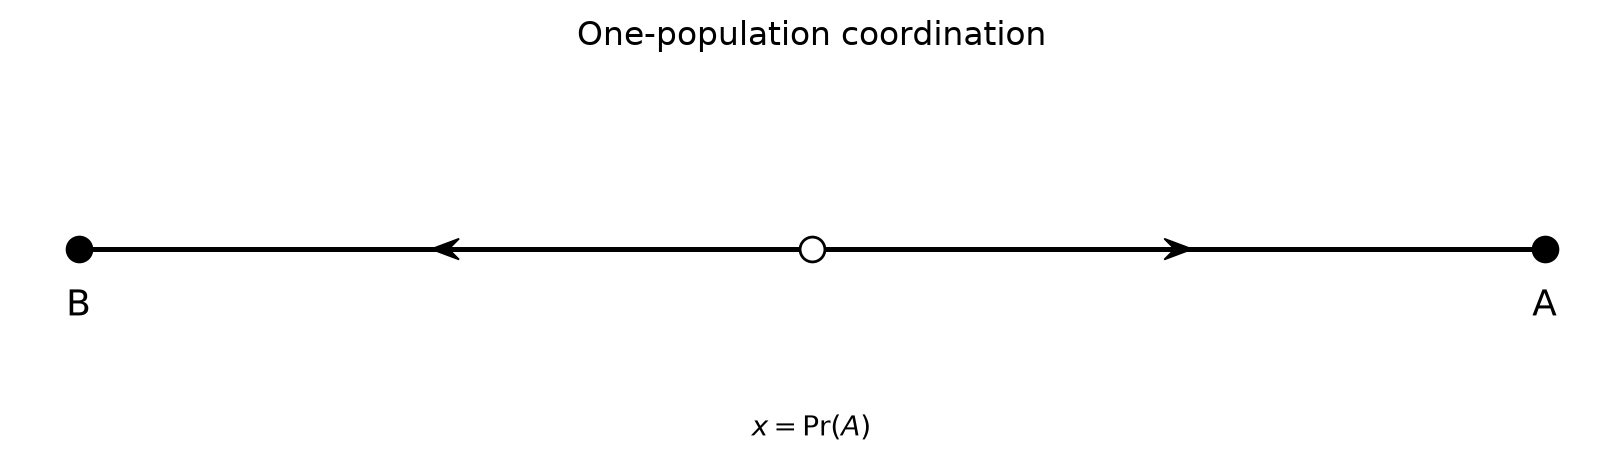

In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.close("all")


coordination_1d = pn.Game(
    name="One-population coordination",
    payoffs=[[1, 0], [0, 1]],
    strategy_labels=["A", "B"],
)
fig, ax = pn.phase_portrait(
    game=coordination_1d, figsize=(8, 2.2), xlabel=r"$x=\Pr(A)$",
    trajectory_color="black", trajectory_linewidth=1.8,
    arrow_size=.04, arrow_width=.015,
    equilibrium_size=80, sink_color="black", source_color="white",
    equilibrium_edgecolor="black",
)
plt.show()

By default, pyNamo places an arrow between each pair of neighboring equilibria. To choose arrow positions yourself, pass their frequencies as `trajectory_arrows`, for example `[0.2, 0.8]`; use an empty list, `[]` to hide the arrows. The game supplies the labels at the endpoints, while `xlabel` adds an optional caption.

The next example shows a special case. Its two payoff rows are identical, so neither strategy has a fitness advantage at any frequency. Every point on the phase line is therefore an equilibrium, shown as a continuous colored line rather than as isolated circles. Use `continuum_color` to change that color.


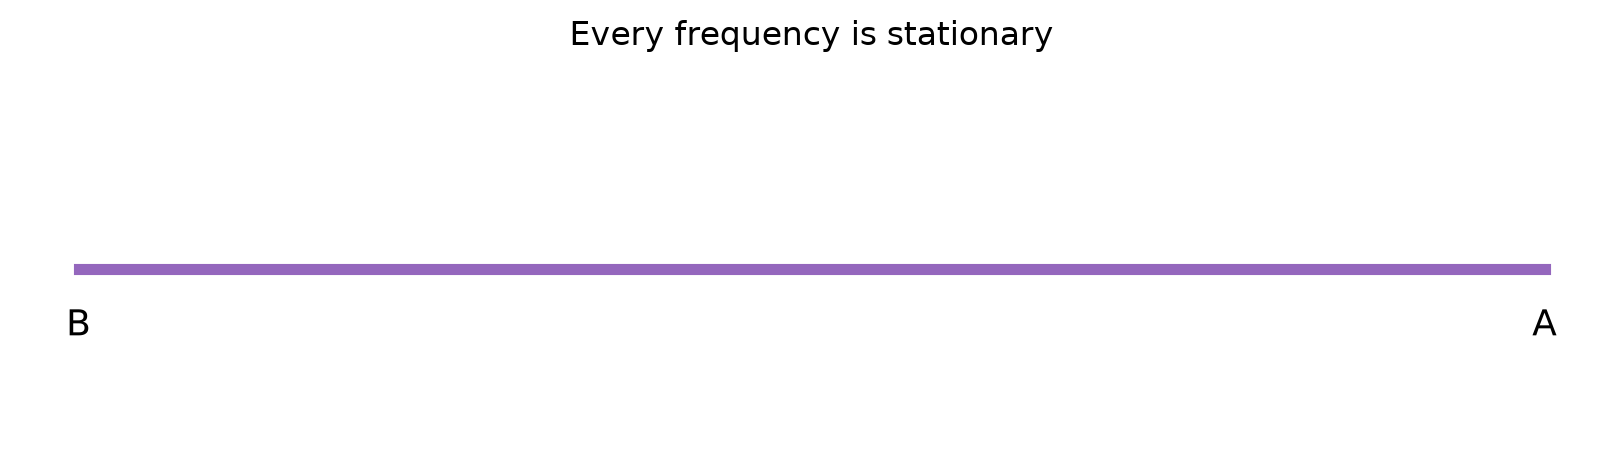

In [10]:
neutral_1d = pn.Game(
    name="Every frequency is stationary",
    payoffs=[[2, 1], [2, 1]],
    strategy_labels=["A", "B"],
)
fig, ax = pn.phase_portrait(
    game=neutral_1d,
    figsize=(8, 2.2),
    continuum_color="tab:purple",
)
plt.show()

### 1-population, 3-strategy game

For a symmetric two-player game with three strategies (1Pop3S), pass a single 3 × 3 payoff matrix to pn.Game

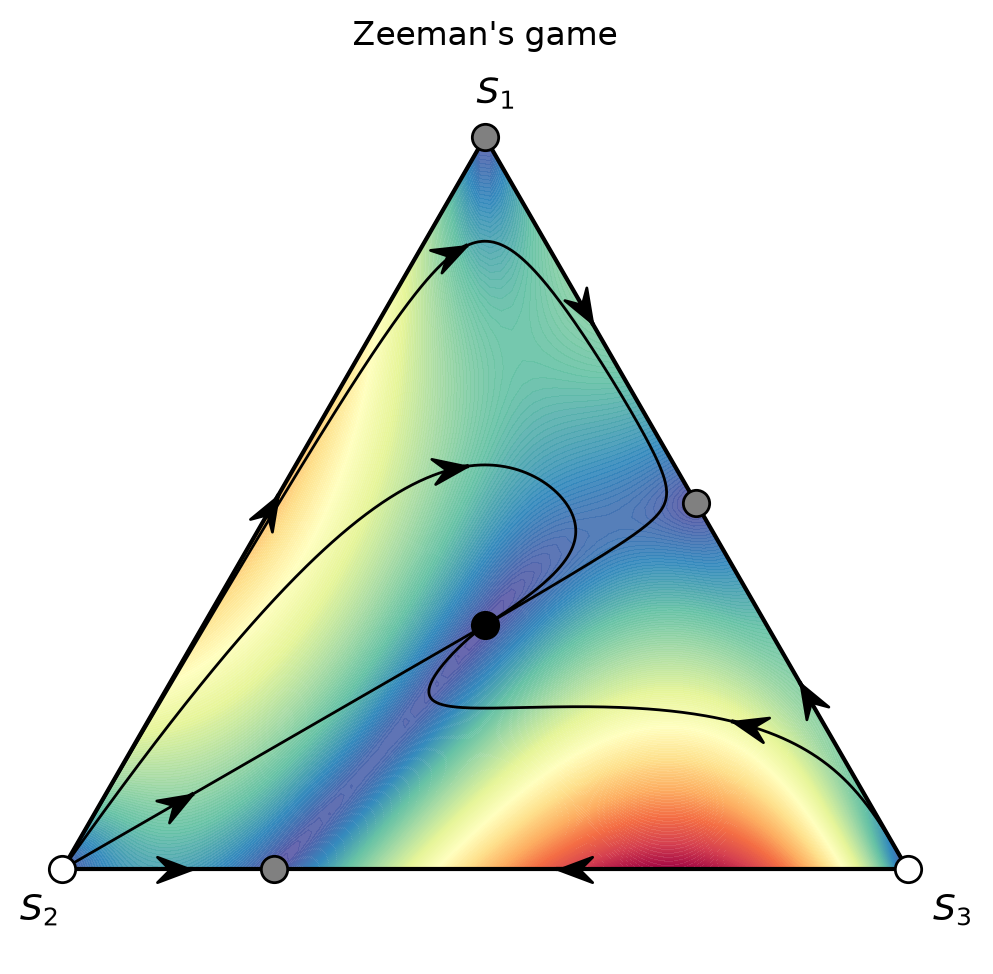

In [11]:
%matplotlib inline
plt.close("all")

import numpy as np
import matplotlib.pyplot as plt

#Reproducing the example from Alexander (2023; Fig.16).
zeeman_like_game = pn.Game(
    name="Zeeman's game",
    payoffs=np.array([
        [1, 1, 1],
        [0, 0, 3],
        [2, 1, 0],
    ], dtype=float),
    strategy_labels=["$S_1$", "$S_2$", "$S_3$"],
)

fig, ax = pn.phase_portrait(
    game=zeeman_like_game,
    starts=[
        [0.10, 0.80],
        [0.55, 0.25],
        [0.2, 0.10],
        [0.5, 0.5],
        [0, 0.85],
        [0, 0.4],
        [0.25, 0],
        [0.75, 0],
        [0.85,0.1]
    ],
    tmax=30,
    trajectory_arrows=[0.001],
    trajectory_color="black",
    trajectory_linewidth=1.0,
    speed_cmap=plt.cm.Spectral_r,
    speed_grid=80,
    speed_levels=200,
    sink_color="black",
    saddle_color="gray",
    source_color="white",
    equilibrium_size=90,
)

plt.show()

### 1-population, 4-strategy game

For a one-population game with four strategies, pass one $4\times4$ payoff matrix to `pn.Game`. The state lies in a tetrahedron. Its first three coordinates are the frequencies of $A$, $B$, and $C$; the fourth frequency is $x_D=1-x_A-x_B-x_C$.

In this simple example, each row has a constant payoff. Fitness therefore ranks the strategies as $A>B>C>D$ at every population state. The trajectories move toward the all-$A$ vertex. Rotate the figure to see the paths through the tetrahedron.

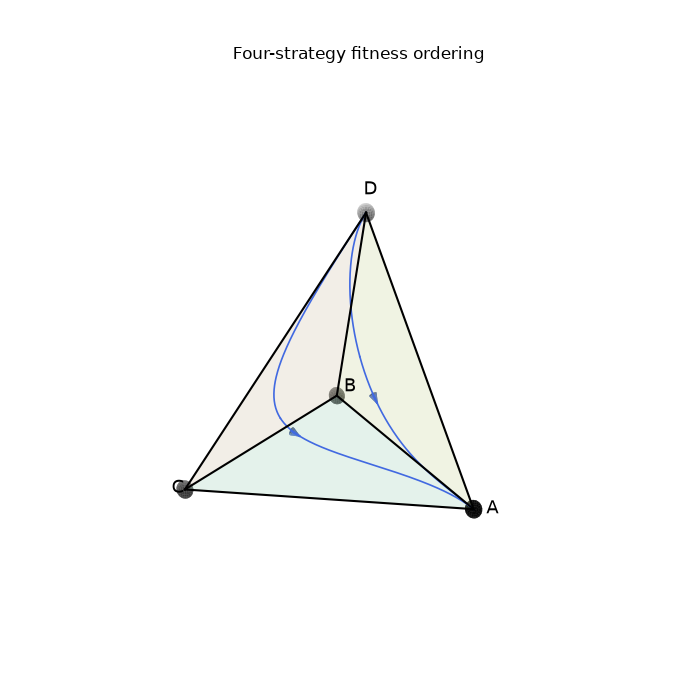

In [12]:
%matplotlib widget
plt.close("all")

four_strategy_fitness_game = pn.Game(
    name="Four-strategy fitness ordering",
    payoffs=np.array([
        [3, 3, 3, 3],
        [2, 2, 2, 2],
        [1, 1, 1, 1],
        [0, 0, 0, 0],
    ], dtype=float),
    strategy_labels=["A", "B", "C", "D"],
)

fig, ax = pn.phase_portrait(
    game=four_strategy_fitness_game,
    starts=[[0.2, 0.3, 0.1], [0.1, 0.2, 0.5]],
    figsize=(7, 7),
    view_elev=25,
    view_azim=35,
    show_faces=True,
    face_alpha=0.15,
    tmax=20,
    trajectory_color="royalblue",
    trajectory_linewidth=1.2,
)
plt.show()
pn.interactive.detach_widget_figure(figure=fig)

### Labels and mathematical notation


Labels passed to `pn.Game` are Matplotlib text labels. They can include simple LaTeX-style mathematical notation, for example `"$S_1$"`, `"$x = P(A)$"`, or `"$\\alpha$"`.

By default, pyNamo does not require a full LaTeX installation. Matplotlib's built-in mathtext engine can render many common mathematical labels. This default is safer for cloud environments such as Binder and Colab.

Advanced users who want Matplotlib to render all text through an external LaTeX installation can enable:

```python
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True
```

This requires LaTeX to be installed and visible to Matplotlib. It is not enabled by default because cloud environments may not provide LaTeX.


### 2-population, 2-strategy game

To define a custom asymmetric 2-player / 2-strategy game (`2Pop2S` in pyNamo nomenclature), provide one payoff matrix per player.

Each matrix uses its recipient as the **focal player**: its rows are that player's own strategies, and its columns are the other player's strategies. Therefore, the first matrix has player 1's strategies as rows and player 2's as columns, while the second matrix has player 2's strategies as rows and player 1's as columns.

The `2Pop2S` game class can also represent a symmetric interaction studied as two-population dynamics. When both populations have the same ordered strategies and the same focal-player payoff rule, pass the same matrix for both players, as in `pn.examples.games.two_population_hawk_dove`.


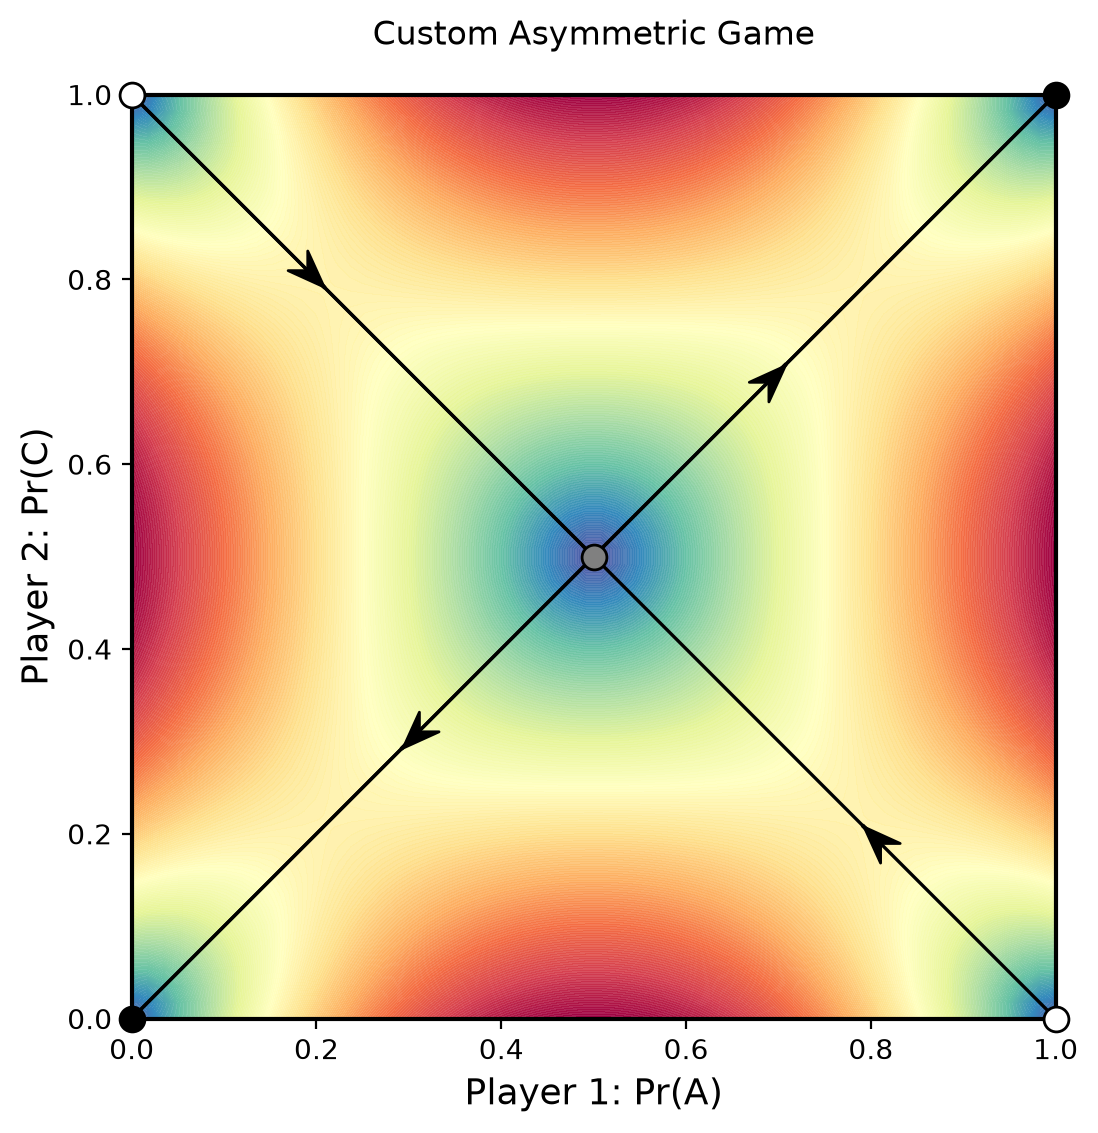

In [10]:
%matplotlib inline
plt.close("all")

custom_asymmetric_game = pn.Game(
    name="Custom Asymmetric Game",
    payoffs=(
        # Player 1 payoff matrix.
        # Rows: Player 1 strategies.
        # Columns: Player 2 strategies.
        np.array([
            [3, 0],
            [1, 2],
        ], dtype=float),

        # Player 2 payoff matrix.
        # Rows: Player 2 strategies.
        # Columns: Player 1 strategies.
        # It differs from player 1's focal-player matrix, so this game is asymmetric.
        np.array([
            [2, 1],
            [0, 3],
        ], dtype=float),
    ),
    player_strategy_labels=[
        ["A", "B"],
        ["C", "D"],
    ],
    player_labels=["Player 1", "Player 2"],
    symmetric=False,
)

fig, ax = pn.phase_portrait(
    game=custom_asymmetric_game,
    starts=[
        [0.2, 0.8],
        [0.8, 0.2],
        [0.3, 0.3],
        [0.7, 0.7],
    ],
    tmax=40,
    trajectory_arrows=[0.001],
    speed_cmap=plt.cm.Spectral_r,
    speed_levels=200,
)

plt.show()

### 3-population, 2-strategy game

For `3Pop2S` games, pyNamo represents three players or populations, each with two strategies. This representation can be used for genuinely asymmetric games, but also for symmetric games studied with one state variable per player/population.

The user is required to provide one payoff tensor per player. All three tensors are indexed by the same action profiles:

$$
A^{(p)}_{i,j,k}
$$

where $p$ is the player receiving the payoff, $i$ is player 1's strategy, $j$ is player 2's strategy, and $k$ is player 3's strategy. Thus:

$$
A^{(1)}_{i,j,k}
$$

is player 1's payoff at action profile $(i, j, k)$,

$$
A^{(2)}_{i,j,k}
$$

is player 2's payoff at the same action profile, and

$$
A^{(3)}_{i,j,k}
$$

is player 3's payoff at the same action profile. The state is:

$$
(x,y,z) \in [0,1]^3
$$

where each coordinate is the probability that the corresponding player uses their first listed strategy.

/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/analysis.py:177: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated rest-point families are not expanded into points; vertices and identifiable isolated points are retained.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/drawer.py:1328: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


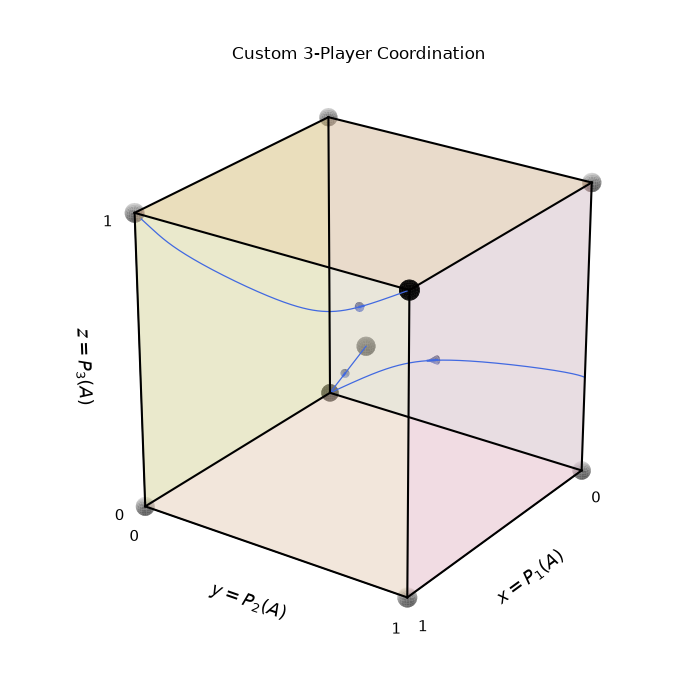

In [13]:
%matplotlib widget

coordination_tensor = np.zeros((2, 2, 2), dtype=float)

for i in (0, 1):
    for j in (0, 1):
        for k in (0, 1):
            if i == j == k:
                coordination_tensor[i, j, k] = 1.0

custom_3p2s_coordination = pn.Game(
    name="Custom 3-Player Coordination",
    payoffs=(
        # The same tensor is used for all three players.
        # Substantively, this is a symmetric coordination game.
        # We still use the 3Pop2S representation because we want one
        # state variable per player/population.
        coordination_tensor,
        coordination_tensor,
        coordination_tensor,
    ),
    player_strategy_labels=[
        ["A", "B"],
        ["A", "B"],
        ["A", "B"],
    ],
    player_labels=["Player 1", "Player 2", "Player 3"],
    strategy_labels=[
        "$x = P_1(A)$",
        "$y = P_2(A)$",
        "$z = P_3(A)$",
    ],
    symmetric=False,
)

fig, ax = pn.phase_portrait(
    game=custom_3p2s_coordination,
    figsize=(7, 7),
    view_elev=25,
    view_azim=35,
    show_faces=True,
    face_alpha=0.3,
    starts=[
        [0.2, 0.2, 0.2],
        [0.8, 0.7, 0.8],
        [0.3, 0.6, 0.4],
    ],
    tmax=40,
    trajectory_arrows=[0.001],
    trajectory_color="royalblue",
    trajectory_linewidth=0.9,
)

plt.show()
pn.interactive.detach_widget_figure(figure=fig)

## 6. Coordinate conventions

For `1Pop3S` games with strategy labels `[A, B, C]`, a state vector

$$
x = \begin{pmatrix}0.2 \\ 0.3 \\ 0.5\end{pmatrix}
$$

means $20\%$ strategy `A`, $30\%$ strategy `B`, and $50\%$ strategy `C`.

For `2Pop2S` asymmetric games, a state vector `[x, y]` means that player 1 uses its first listed strategy with probability $x$, and player 2 uses its first listed strategy with probability $y$. Note that since the game is asymmetric it is possible that $x+y>1$. The only constraint is that both $x \in [0,1]$ and $y \in [0,1]$.

### Initial conditions

The `starts` argument specifies the initial conditions of the trajectories. It is a list whose entries are themselves lists:

```python
starts=[
    [0.2, 0.4],
    [0.7, 0.1],
]
```

Each inner list is one initial condition. Therefore, the length of `starts` determines the number of trajectories.

The number of coordinates in each initial condition depends on the game class.

For `2Pop2S` games, each initial condition has two coordinates:

$$
[x,y]
$$

where $x$ is the probability that player 1 uses its first listed strategy, and $y$ is the probability that player 2 uses its first listed strategy.

For `3Pop2S` games, each initial condition has three coordinates:

$$
[x,y,z]
$$

where each coordinate is the probability that the corresponding player uses its first listed strategy.

For symmetric `1Pop3S` games, the full state is:

$$
(x_1,x_2,x_3)
$$

but only the first two coordinates are passed:

$$
[x_1,x_2]
$$

The third coordinate is inferred as:

$$
x_3 = 1 - x_1 - x_2.
$$

For symmetric `1Pop4S` games, only the first three coordinates are passed:

$$
[x_1,x_2,x_3]
$$

The fourth coordinate is inferred as:

$$
x_4 = 1 - x_1 - x_2 - x_3.
$$

This reduced-coordinate convention keeps the plotted state space two-dimensional for `1Pop3S` games and three-dimensional for `1Pop4S` games.

When `starts` is omitted, `trajectory_number` selects the exact number of automatically generated initial conditions. pyNamo recursively divides a simplex or product of simplexes into approximately equal regions and uses each region's centroid as a deterministic start. Supplying `random_state` instead produces reproducible random starts.

For `1Pop3S` and `2Pop2S`, automatically generated starts also enable one-dimensional flow on every invariant boundary. Boundary arrows are placed halfway between consecutive edge equilibria. Explicit `starts` disable this boundary flow by default; use `show_edge_flow=True` to combine explicit starts with boundary flow, or `show_edge_flow=False` to hide it.


## 7. Speed fields, vector fields, and trajectories

A speed field shows the norm of the vector field at each state $x$:

$$
\text{speed}(x) = \lVert F(x) \rVert.
$$


A vector field shows the local direction of motion. Trajectories show paths through the state space from chosen starting points. By default, pyNamo plots both the forward and backward trajectory through each starting point.

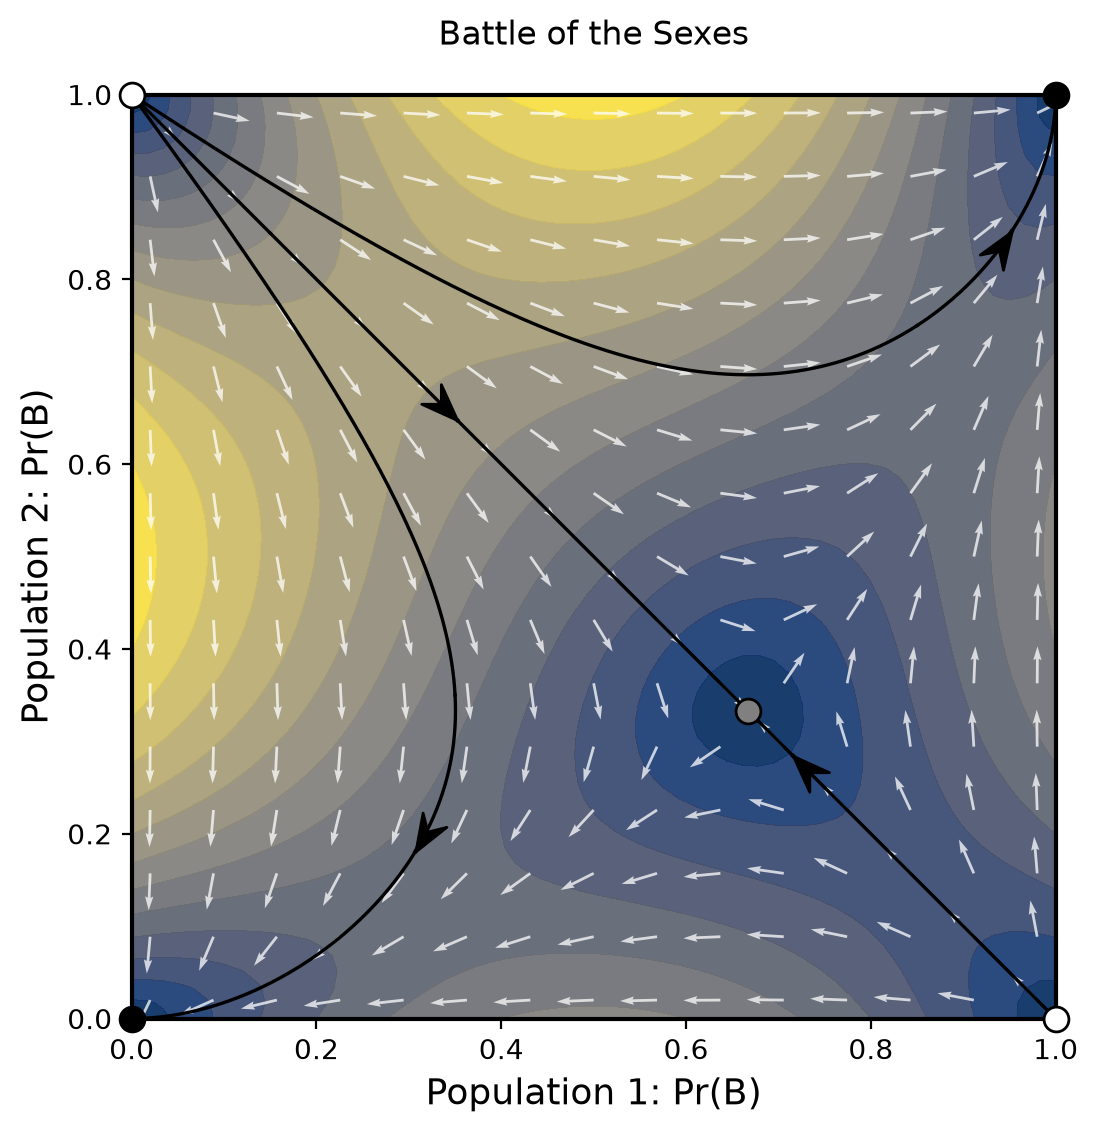

In [12]:
%matplotlib inline
plt.close("all")

fig, ax = pn.phase_portrait(
    game=pn.examples.games.battle_of_the_sexes,
    starts=[
        [0.15, 0.85],
        [0.35, 0.35],
        [0.75, 0.25],
        [0.85, 0.75],
    ],
    show_speed=True,
    show_vector_field=True,
    vector_color="white",
    speed_cmap=plt.cm.cividis,
)
plt.show()


## 8. Equilibria and stability

pyNamo detects isolated rest points and classifies stability using the linearization restricted to admissible directions in the state space. The table also reports static equilibrium concepts: Nash, ESS, and strict Nash.

In [13]:
pn.equilibrium_table(game=pn.examples.games.good_rps)

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 1.0]",saddle,False,False,False,"[2.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0, 0.0]",saddle,False,False,False,"[2.0, -1.0]","[[0.0, 1.0], [0.707107, -0.707107]]",None
2,"[0.333333, 0.333333, 0.333333]",sink,True,True,False,"[(-0.166667+0.866025j), (-0.166667-0.866025j)]","[[0.707107, (-0.353553-0.612372j)], [0.707107,...",None
3,"[1.0, 0.0, 0.0]",saddle,False,False,False,"[-1.0, 2.0]","[[1.0, 0.0], [-0.707107, 0.707107]]",None


## 9. Stability classification used by pyNamo

For the admissible linearization, pyNamo uses the following conservative classification logic.

- **Sink**: all admissible eigenvalues have negative real part.
- **Source**: all admissible eigenvalues have positive real part.
- **Saddle**: admissible eigenvalues have both positive and negative real parts.
- **Center**: relevant eigenvalues have zero real part and nonzero imaginary part.
- **Unstable**: at least one admissible eigenvalue has positive real part, but zero or unsupported directions prevent distinguishing source from saddle.
- **Undetermined**: the eigenvalue-based criteria do not determine the case.

If the eigenvalue-based classification is undetermined, pyNamo checks whether the equilibrium has been established to be an ESS. If so, it is classified as a sink; otherwise, it remains undetermined and a warning is emitted.

Eigenvalue computations are numerical. Stability classification uses a tolerance of $10^{-9}$ when comparing eigenvalue components with zero. Boundary eigenpair filtering uses a separate tolerance of $10^{-7}$ to handle numerical noise and assess admissible directions.

### Warnings

pyNamo uses warnings when the mathematical analysis detects a limitation rather than silently forcing a misleading conclusion. The main warnings are:

- `InconclusiveStabilityWarning`: emitted when the implemented linear-stability criteria do not determine the local stability classification.
- `DegenerateEquilibriumWarning`: emitted when the equilibrium equations contain non-isolated solution sets, such as equilibrium edges or continua (see the next section for more on this).
- `PlottingWarning`: emitted when plotting requires a visual convention, for example drawing `unstable` equilibria with the same color as sources.

Warnings do not necessarily mean that the computation failed. They usually mean that the result should be interpreted with the stated caveat.

## 10. Degenerate equilibrium sets

Some games have non-isolated equilibrium sets. pyNamo warns about these cases and does not automatically plot equilibrium manifolds. The cell below shows how to manually inspect the Dove-Retaliator edge in the Hawk-Dove-Retaliator game from McElreath & Boyd (2007). The payoff matrix is:

$$
A =
\begin{array}{c|ccc}
 & H & D & R \\
\hline
H & \frac{v-c}{2} & v & \frac{v-c}{2} \\
D & 0 & \frac{v}{2} & \frac{v}{2} \\
R & \frac{v-c}{2} & \frac{v}{2} & \frac{v}{2}
\end{array}
$$

where $H$ is Hawk, $D$ is Dove, and $R$ is Retaliator. In the code below, we use:

$$
v = 2, \qquad c = 3.
$$

With these values, the Dove-Retaliator edge is a continuum of rest points. The edge itself is invariant; the colors in the plot indicate transverse stability with respect to invasion by Hawk.

/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/analysis.py:177: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated rest-point families are not expanded into points; vertices and identifiable isolated points are retained.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/drawer.py:748: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  result = analysis.analyze_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/drawer.py:1328: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibi

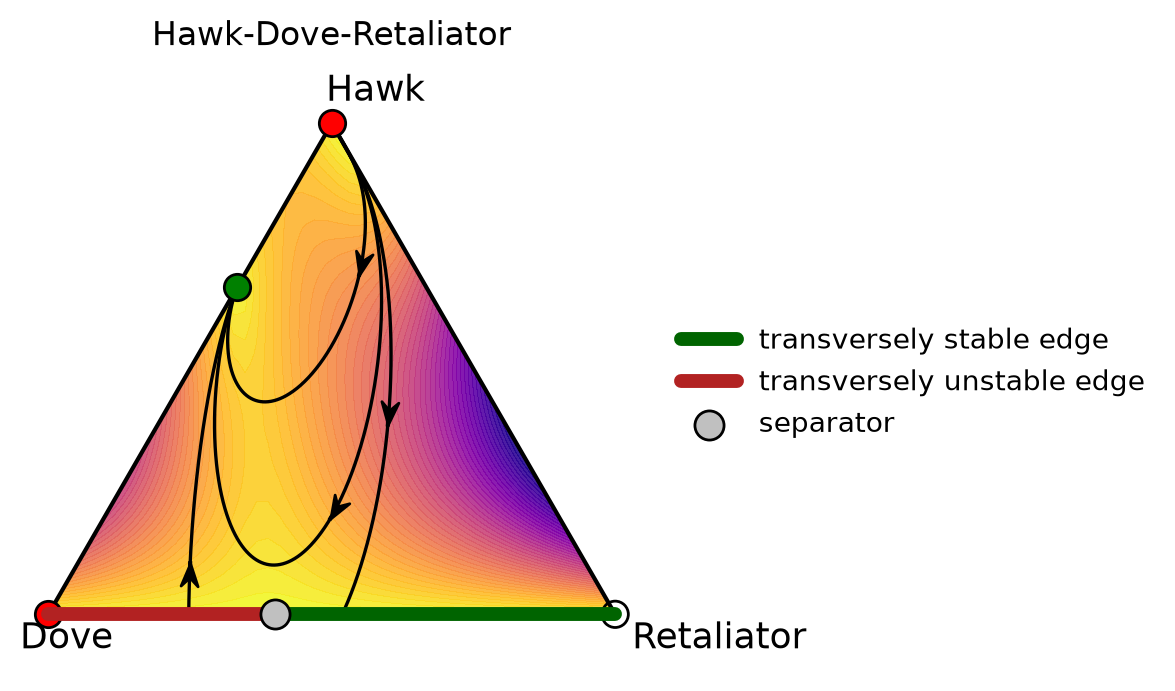

/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/analysis.py:262: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  return analyze_equilibria(game).to_dataframe(ndigits=ndigits)


,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.666667, 0.333333, 0.0]",sink,True,True,False,"[-0.333333, -0.333333]","[[0.707107, -0.707107], [0.707107, -0.707107]]",NaN
1,"[1.0, 0.0, 0.0]",unstable,False,False,False,"[0.0, 0.5]","[[1.0, 0.0], [-0.707107, 0.707107]]",NaN
2,"[0.0, 1.0, 0.0]",unstable,False,False,False,"[0.0, 1.0]","[[0.0, 1.0], [0.707107, -0.707107]]",NaN
3,"[0.0, 0.0, 1.0]",undetermined,True,False,False,"[-1.5, 0.0]","[[1.0, 0.0], [0.0, 1.0]]",Stability classification is inconclusive for e...


In [14]:
%matplotlib inline
plt.close("all")

g = pn.examples.games.hawk_dove_retaliator
A = g.payoff_data

fig, ax = pn.phase_portrait(
    game=g,
    starts=[
        [0.4, 0.2],
        [0.2, 0.4],
        [0.1, 0.7],
        [0.7, 0.1],
    ],
    tmax=120,
    trajectory_arrows=[0.001],
    trajectory_zorder=40,
    speed_cmap=plt.cm.plasma_r,
    speed_grid=50,
    speed_levels=50,
    sink_color="green",
    saddle_color="gold",
    source_color="red",
    equilibrium_size=90,
    equilibrium_zorder=45,
)

# On the Dove-Retaliator edge, x_Hawk = 0. Every point on this edge
# is a rest point because Dove and Retaliator receive identical payoffs
# against Dove/Retaliator mixtures. Transverse stability is determined by
# whether a rare Hawk has positive or negative growth.
dove_grid = np.linspace(0, 1, 1001)
rare_hawk_growth = []

for dove_share in dove_grid:
    state = np.array([0.0, dove_share, 1.0 - dove_share])
    payoff_hawk = A[0] @ state
    average_payoff = state @ A @ state
    rare_hawk_growth.append(payoff_hawk - average_payoff)

rare_hawk_growth = np.array(rare_hawk_growth)
stable_mask = rare_hawk_growth < 0
unstable_mask = rare_hawk_growth > 0


def plot_edge_segments(mask, color, label):
    idx = np.where(mask)[0]
    if idx.size == 0:
        return

    breaks = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, breaks)

    for segment in segments:
        d0 = dove_grid[segment[0]]
        d1 = dove_grid[segment[-1]]

        p0 = pn.drawer.simplex_to_plane_2p3s(x=0.0, y=d0)
        p1 = pn.drawer.simplex_to_plane_2p3s(x=0.0, y=d1)

        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            color=color,
            linewidth=5,
            zorder=50,
            solid_capstyle="round",
            label=label,
        )
        label = None


plot_edge_segments(stable_mask, "darkgreen", "transversely stable edge")
plot_edge_segments(unstable_mask, "firebrick", "transversely unstable edge")

# For the default v=2, c=3, the separator is at Dove share c/(v+c)=3/5.
separator_dove_share = 3 / 5
separator = pn.drawer.simplex_to_plane_2p3s(x=0.0, y=separator_dove_share)
ax.scatter(
    separator[0],
    separator[1],
    s=110,
    color="silver",
    edgecolors="black",
    zorder=55,
    label="separator",
)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

pn.equilibrium_table(game=g)

## 11. Why ESS is not reported for games with more than one population

In pyNamo, an ESS is currently evaluated only for games represented by a single symmetric payoff matrix. Therefore, 2Pop2S and 3Pop2S games report `ESS = NA` in the equilibrium table, even when the underlying interaction is symmetric. The 2Pop2S and 3Pop2S representations describe multi-population dynamics; the ESS test applies to the one-population symmetric model only.

We illustrate this behavior below with the two-population Stag-Hunt game.

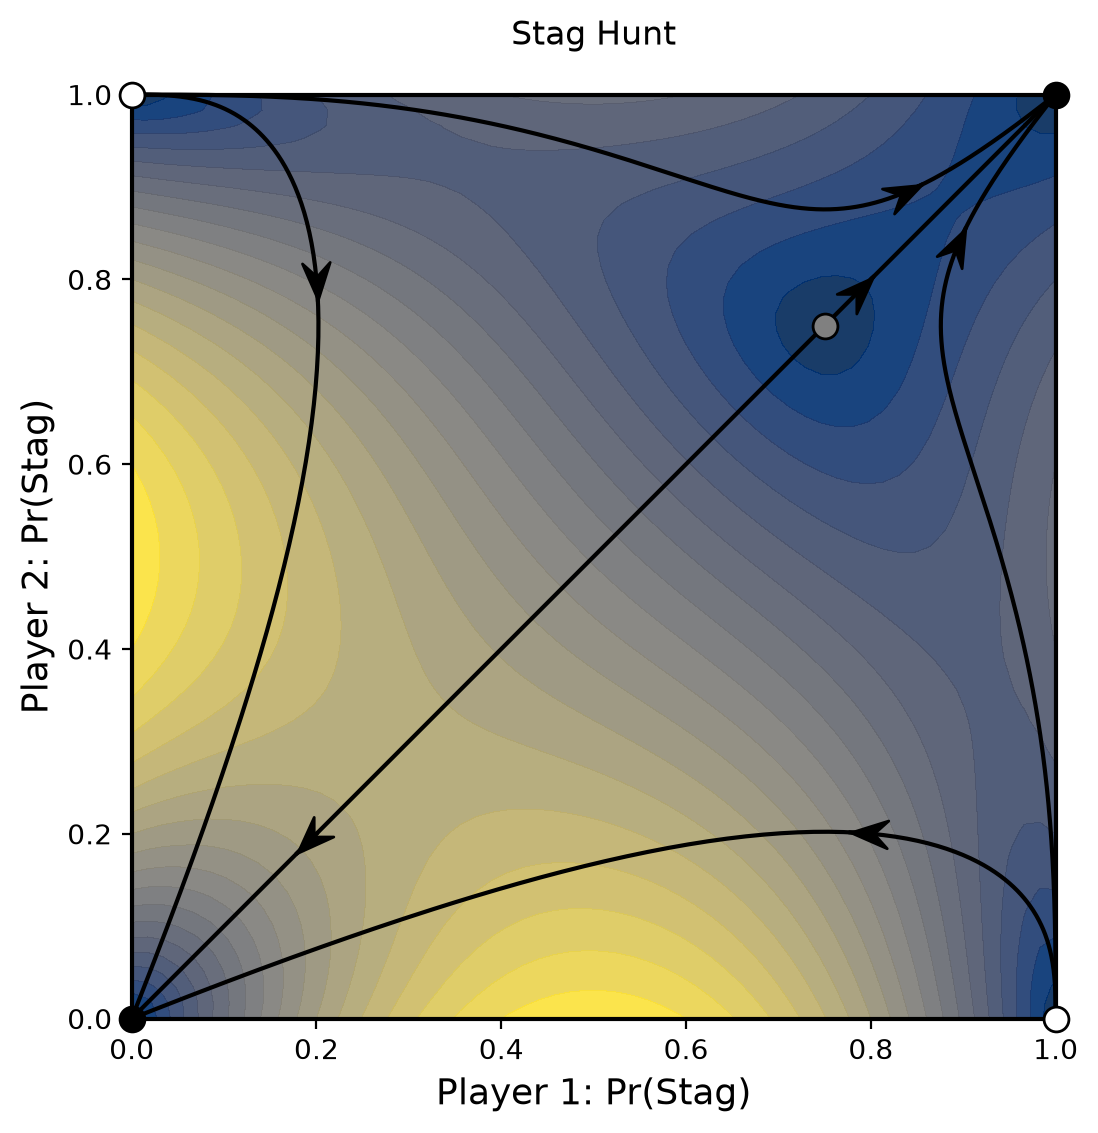

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0]",sink,True,NA,True,"[-3.0, -3.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0]",source,False,NA,False,"[1.0, 3.0]","[[1.0, 0.0], [0.0, 1.0]]",None
2,"[0.75, 0.75]",saddle,True,NA,False,"[0.75, -0.75]","[[0.707107, 0.707107], [-0.707107, 0.707107]]",None
3,"[1.0, 0.0]",source,False,NA,False,"[3.0, 1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
4,"[1.0, 1.0]",sink,True,NA,True,"[-1.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None


In [15]:
%matplotlib inline
plt.close("all")

fig, ax = pn.phase_portrait(
    game=pn.examples.games.stag_hunt,
    starts=[
        [0.2, 0.2],
        [0.2, 0.8],
        [0.8, 0.2],
        [0.8, 0.8],
        [0.85, 0.9],
        [0.9, 0.85]
    ],
    tmax=60,
    trajectory_arrows=[0.001],
    trajectory_linewidth=1.5,
    speed_cmap=plt.cm.cividis,
    speed_levels=20,
)
plt.show()

pn.equilibrium_table(game=pn.examples.games.stag_hunt)

## 12. Tips for viewing 3D phase portraits

The tetrahedron (`1Pop4S`) and cube (`3Pop2S`) are harder to read than a 2D figure. The two examples below show how the viewing angle and visible surfaces affect the interpretation of trajectories. Use `view_elev` and `view_azim` to choose the angle, `show_faces`, `face_colors`, and `face_alpha` to control the faces, and `show_equilibria` and `equilibrium_size` to control equilibrium markers.

When enabled, trajectory arrows appear as small cones along the curves. The tetrahedron example displays an arrow on each trajectory; the cube example sets `trajectory_arrows=[]` to keep its four trajectories easier to follow.

A good starting point for understanding a 3D case is to study what happens on the faces of its state space. You can do this by defining subgames that restrict the full game to a face (see the face-plot cells below). **However, even examining every face does not determine what happens to trajectories starting in the 3D interior, where all strategies are present. Interior dynamics can differ sharply from face dynamics: the interior can even display chaotic behavior or attractors that do not derive from face behavior** (see at the end of the notebook an illustration with the built-in example `pn.examples.games.chaotic_four_strategy_game`).

In this notebook, drag the interactive figure to rotate it and inspect paths that overlap from a single viewpoint.

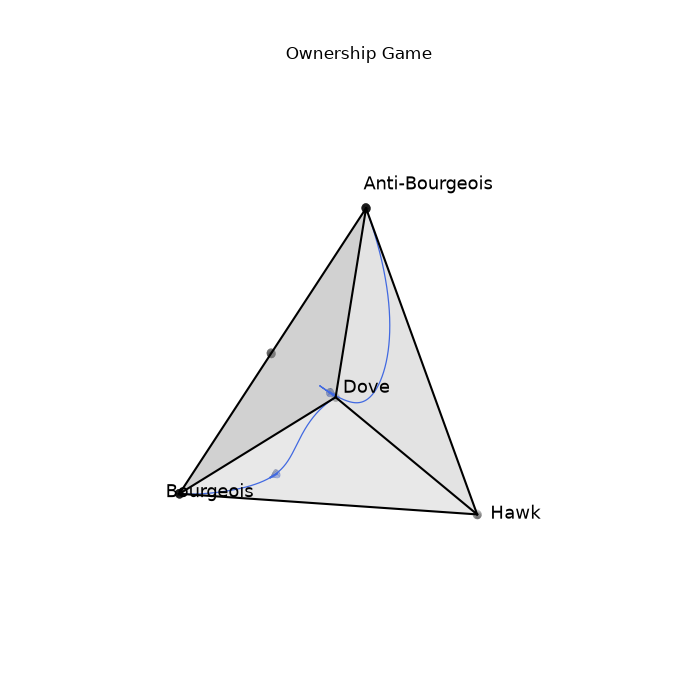

In [14]:
%matplotlib widget

fig, ax = pn.phase_portrait(
    game=pn.examples.games.ownership_game,
    figsize=(7, 7),
    view_elev=25,
    view_azim=35,
    show_faces=True,
    face_colors=[
        "#f2f2f2",
        "#d9d9d9",
        "#bfbfbf",
        "#969696",
    ],
    face_alpha=0.3,
    starts=[
        [0.22, 0.25, 0.25],
        [0.20, 0.20, 0.60],
    ],
    tmax=30,
    trajectory_arrows=[0.001],
    trajectory_color="royalblue",
    trajectory_linewidth=0.9,
    equilibrium_size=20,
)

plt.show()
pn.interactive.detach_widget_figure(figure=fig)

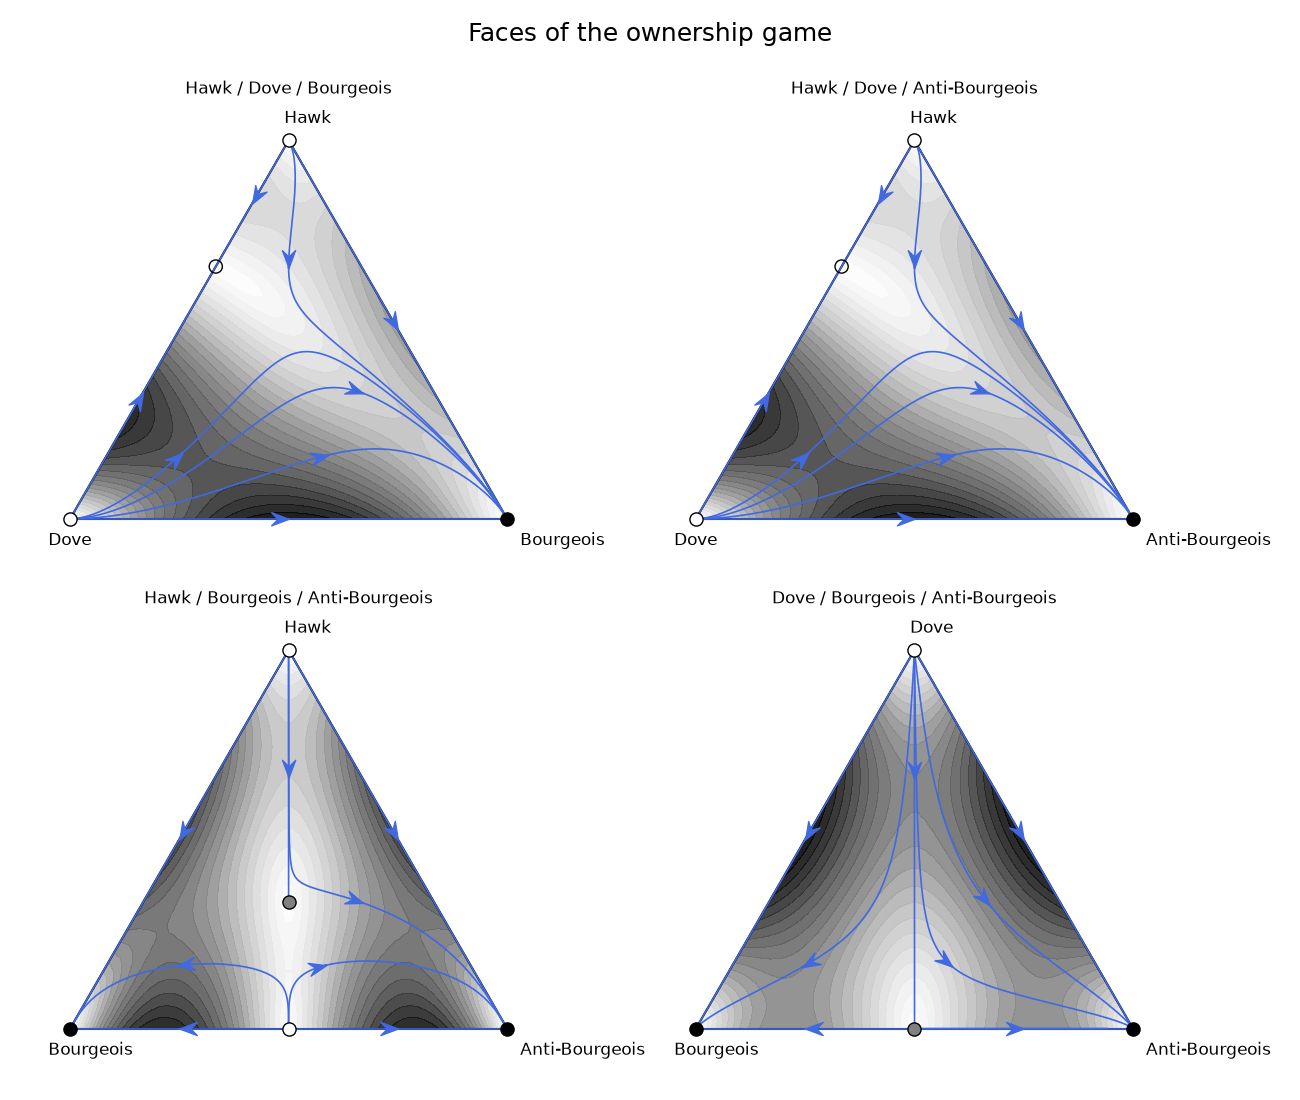

In [24]:
from itertools import combinations

ownership_game = pn.examples.games.ownership_game
payoffs = np.asarray(ownership_game.payoff_data, dtype=float)
labels = ownership_game.strategy_labels

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 11))

for ax, indices in zip(axes.flat, combinations(range(4), 3)):
    face_labels = [labels[i] for i in indices]

    face_game = pn.Game(
        name=" / ".join(face_labels),
        payoffs=payoffs[np.ix_(indices, indices)],
        strategy_labels=face_labels,
    )

    pn.phase_portrait(
        game=face_game,
        fig=fig,
        ax=ax,
        trajectory_number=4,
        show_edge_flow=True,
        tmax=100,
        show_speed=True,
        speed_cmap=plt.cm.Greys,
        speed_levels=20,
        trajectory_arrows=[0.001],
        trajectory_color="royalblue",
        trajectory_linewidth=1.2,
        simplex_font_size=12,
        equilibrium_size=90,
        trajectory_zorder=35
    )
    
fig.suptitle("Faces of the ownership game", fontsize=18)
fig.tight_layout(pad=2)
plt.show()

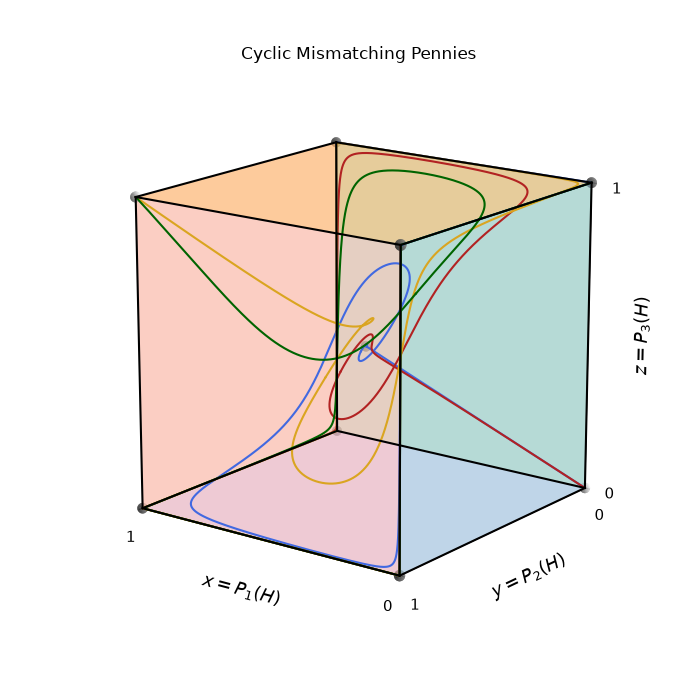

In [17]:
%matplotlib widget

fig, ax = pn.phase_portrait(
    game=pn.examples.games.cyclic_mismatching_pennies,
    figsize=(7, 7),
    view_elev=16,
    view_azim=127,
    show_faces=True,
    face_alpha=0.5,
    starts=[
        [0.52, 0.50, 0.48],
        [0.60, 0.50, 0.40],
        [0.70, 0.45, 0.35],
        [0.20, 0.65, 0.75],
    ],
    tmax=400,
    trajectory_arrows=[],
    trajectory_color=["royalblue", "firebrick", "goldenrod", "darkgreen"],
    trajectory_linewidth=1.5,
    equilibrium_size=25,
)
plt.show()
pn.interactive.detach_widget_figure(figure=fig)

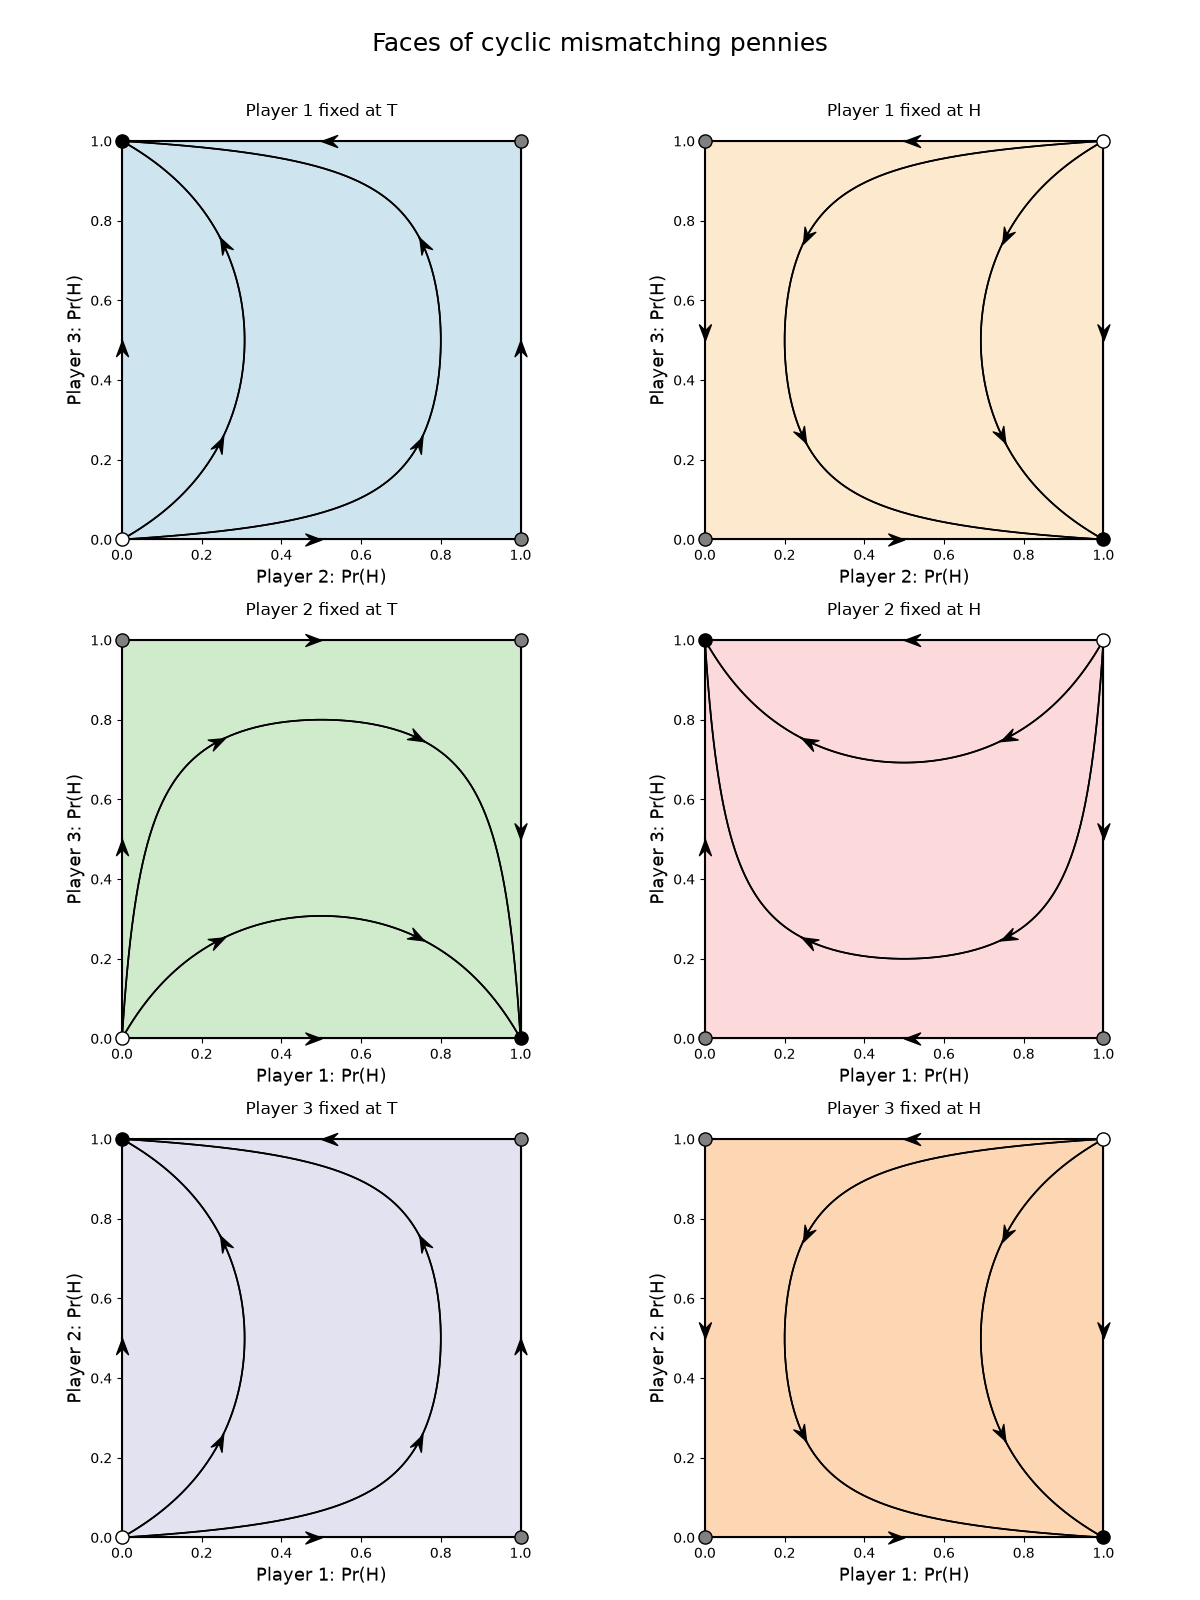

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

cube_game = pn.examples.games.cyclic_mismatching_pennies

cube_face_colors = [
    "#9ecae1",  # x = 0
    "#fdd49e",  # x = 1
    "#a1d99b",  # y = 0
    "#fbb4b9",  # y = 1
    "#c7c7e2",  # z = 0
    "#fdae6b",  # z = 1
]
face_alpha = 0.5

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 16))

for fixed_player in range(3):
    for face_coordinate in (0, 1):
        face_index = 2 * fixed_player + face_coordinate
        ax = axes.flat[face_index]

        # A coordinate of 1 means the first action (H); 0 means the second (T).
        fixed_action = 1 - face_coordinate
        remaining_players = [
            player for player in range(3) if player != fixed_player
        ]

        face_payoffs = []
        for player in remaining_players:
            matrix = np.take(
                cube_game.payoff_data[player],
                indices=fixed_action,
                axis=fixed_player,
            )

            # 2Pop2S expects each player's own actions along its matrix rows.
            if player == remaining_players[1]:
                matrix = matrix.T

            face_payoffs.append(matrix)

        action_label = cube_game.player_strategy_labels[
            fixed_player
        ][fixed_action]

        face_game = pn.Game(
            name=f"Player {fixed_player + 1} fixed at {action_label}",
            payoffs=tuple(face_payoffs),
            player_strategy_labels=[
                cube_game.player_strategy_labels[player]
                for player in remaining_players
            ],
            player_labels=[
                f"Player {player + 1}"
                for player in remaining_players
            ],
            symmetric=False,
        )

        pn.phase_portrait(
            game=face_game,
            fig=fig,
            ax=ax,
            trajectory_number=4,
            show_edge_flow=True,
            tmax=40,
            show_speed=False,
            trajectory_arrows=[0.001],
            trajectory_color="black",
            trajectory_linewidth=1.2,
            trajectory_zorder=35,
            simplex_zorder=30,
            equilibrium_size=90,
        )

        # Apply the same translucent color as the corresponding cube face,
        ax.add_patch(
            Rectangle(
                xy=(0, 0),
                width=1,
                height=1,
                facecolor=cube_face_colors[face_index],
                alpha=face_alpha,
                edgecolor="none",
                zorder=10,
            )
        )

fig.suptitle("Faces of cyclic mismatching pennies", fontsize=18)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()
pn.interactive.detach_widget_figure(figure=fig)

## 13. Saving publication-quality figures

pyNamo returns standard Matplotlib objects. Save figures exactly as you would save any Matplotlib figure.

This cell uses an inline PNG preview. SVG and PDF files are exported directly with `fig.savefig(...)`, independently of the notebook display backend.

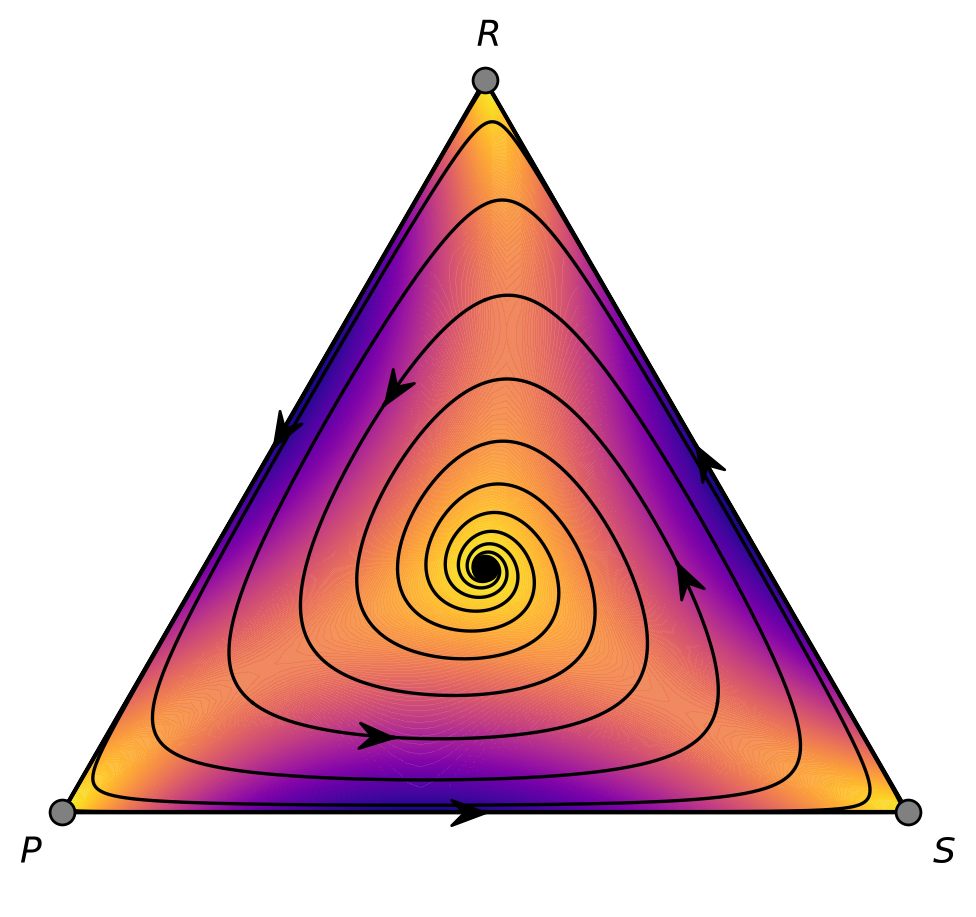

In [18]:
%matplotlib inline
plt.close("all")

fig, ax = pn.phase_portrait(
    game=pn.examples.games.good_rps,
    starts=[
        [0.15, 0.15],
        [0.15, 0.70],
        [0.70, 0.15]
        ],
    speed_cmap=plt.cm.plasma_r,
    trajectory_color="black",
    trajectory_linewidth=1.2,
    show_edge_flow=True,
    speed_levels=200,
)

ax.set_title("")

fig.savefig("good_rps_replicator_dynamics.svg", bbox_inches="tight")
fig.savefig("good_rps_replicator_dynamics.pdf", bbox_inches="tight")
plt.show()

## 14. Advanced customization

This section is optional on a first reading.

Here we deliberately tweak most user-facing parameters of `pn.phase_portrait`. These cells are useful examples to copy from when preparing figures.

For the complete parameter documentation, use Python's `help` function:

```python
help(pn.phase_portrait)
```

In some notebook frontends, abbreviated help such as `pn.phase_portrait?` may truncate long docstrings.


In [19]:
help(pn.phase_portrait)

Help on function phase_portrait in module pynamo_egt.drawer:

phase_portrait(game, *, fig=None, ax=None, figsize=None, view_elev=25, view_azim=35, xlabel=None, ylabel=None, zlabel=None, title_pad=18, starts=None, random_state=None, trajectory_number=4, show_edge_flow=None, simplex_font_size=13, simplex_zorder=30, show_speed=True, speed_grid=60, speed_cmap=<matplotlib.colors.LinearSegmentedColormap object at 0x1073d5700>, speed_levels=12, speed_zorder=10, show_vector_field=False, vector_grid=15, vector_margin=0.02, vector_color='black', vector_alpha=0.75, vector_length=0.04, vector_width=0.003, vector_zorder=15, vector_normalize=True, show_faces=False, face_colors=None, face_alpha=0.15, face_zorder=0, show_trajectories=True, trajectory_step=0.02, trajectory_arrows=None, tmax=45, trajectory_color='black', trajectory_linewidth=None, arrow_size=0.04, arrow_width=0.015, trajectory_zorder=20, show_equilibria=True, sink_color='black', saddle_color='gray', source_color='white', center_color=No

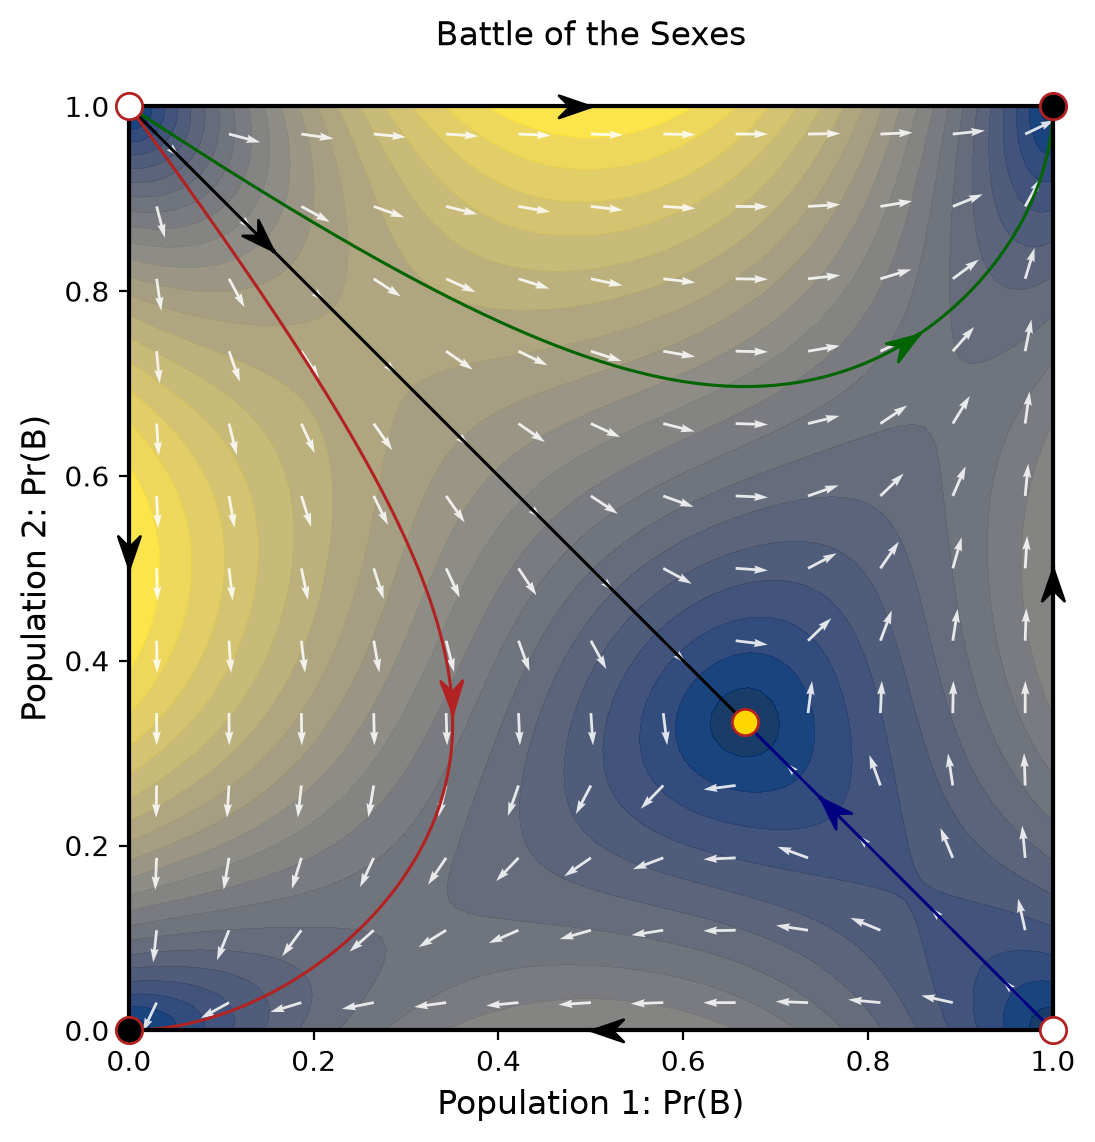

In [20]:
%matplotlib inline
plt.close("all")

fig, ax = pn.phase_portrait(
    game=pn.examples.games.battle_of_the_sexes,
    figsize=(6, 6),
    xlabel="Population 1: Pr(B)",
    ylabel="Population 2: Pr(B)",
    title_pad=22,
    starts=[
        [0.15, 0.85],
        [0.35, 0.35],
        [0.75, 0.25],
        [0.85, 0.75],
    ],
    show_edge_flow=True,
    simplex_font_size=12,
    simplex_zorder=30,
    show_speed=True,
    speed_grid=80,
    speed_cmap=plt.cm.cividis,
    speed_levels=20,
    speed_zorder=5,
    show_vector_field=True,
    vector_grid=13,
    vector_margin=0.03,
    vector_color="white",
    vector_alpha=0.85,
    vector_length=0.035,
    vector_width=0.003,
    vector_zorder=15,
    vector_normalize=True,
    show_faces=False,
    show_trajectories=True,
    trajectory_step=0.015,
    trajectory_arrows=[0.001],
    tmax=30,
    trajectory_color=["black", "firebrick", "navy", "darkgreen"],
    trajectory_linewidth=1.1,
    arrow_size=0.035,
    arrow_width=0.012,
    trajectory_zorder=25,
    show_equilibria=True,
    sink_color="black",
    saddle_color="gold",
    source_color="white",
    center_color="tab:blue",
    equilibrium_size=90,
    equilibrium_edgecolor="firebrick",
    equilibrium_zorder=40,
)
plt.show()

/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/drawer.py:1328: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


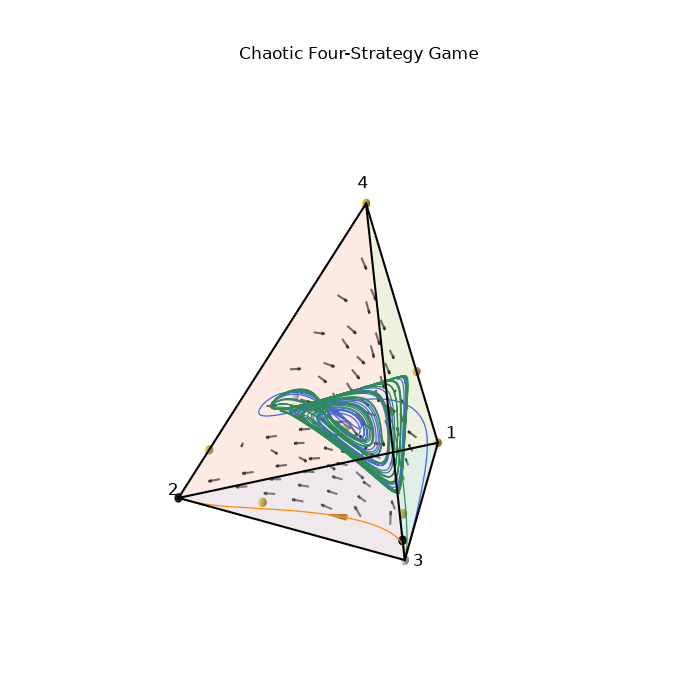

In [21]:
%matplotlib widget

fig, ax = pn.phase_portrait(
    game=pn.examples.games.chaotic_four_strategy_game,
    figsize=(7, 7),
    view_elev=20,
    view_azim=-56,
    xlabel=None,
    ylabel=None,
    zlabel=None,
    title_pad=18,
    starts=[
        [0.22, 0.25, 0.25],
        [0.20, 0.20, 0.60],
        [0.45, 0.10, 0.20],
    ],
    random_state=12,
    simplex_font_size=12,
    simplex_zorder=30,
    show_speed=False,
    speed_grid=60,
    speed_cmap=plt.cm.Spectral,
    speed_levels=12,
    speed_zorder=10,
    show_vector_field=True,
    vector_grid=8,
    vector_margin=0.06,
    vector_color="black",
    vector_alpha=0.65,
    vector_length=0.04,
    vector_width=0.003,
    vector_zorder=15,
    vector_normalize=True,
    show_faces=True,
    face_colors=[
        "#9ecae1",
        "#fdd49e",
        "#a1d99b",
        "#fbb4b9",
    ],
    face_alpha=0.18,
    face_zorder=0,
    show_trajectories=True,
    trajectory_step=0.02,
    trajectory_arrows=[0.001],
    tmax=90,
    trajectory_color=["royalblue", "darkorange", "seagreen"],
    trajectory_linewidth=0.9,
    arrow_size=0.08,
    arrow_width=0.01,
    trajectory_zorder=25,
    show_equilibria=True,
    sink_color="black",
    saddle_color="gold",
    source_color="white",
    center_color="tab:blue",
    equilibrium_size=18,
    equilibrium_edgecolor="black",
    equilibrium_zorder=40,
)
plt.show()
pn.interactive.detach_widget_figure(figure=fig)

## 15. Bifurcation diagrams for symmetric 2×2 games

A bifurcation diagram shows how the equilibria of a game change when one model parameter varies. Define a function that accepts the parameter value and returns a $2 \times 2$ payoff matrix. You can pass this payoff function as the first argument to `bifurcation_diagram`. pyNamo then traces stable and unstable equilibrium branches across a chosen parameter range.

Optional vertical phase lines show the direction of evolution at selected parameter values. They can be labelled to identify distinct equilibrium regimes and connect the equilibrium curves to the one-dimensional phase portraits introduced above.

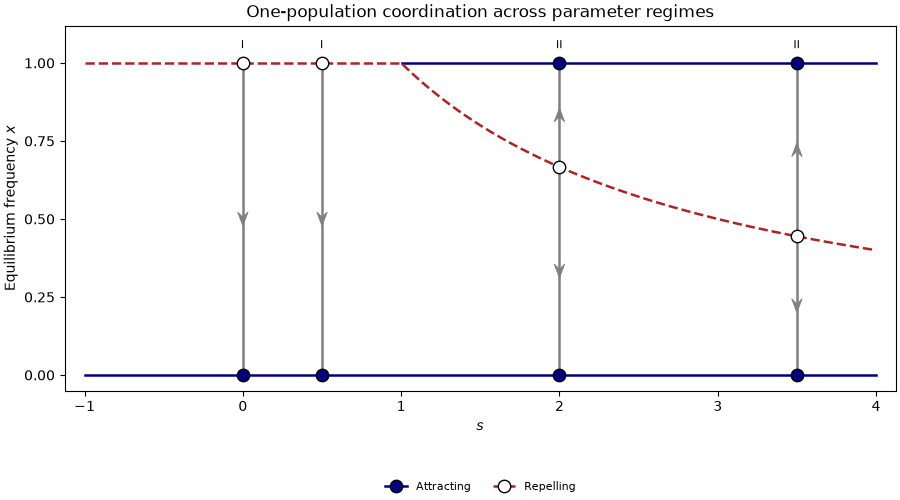

In [22]:
def parameterized_payoffs(s):
    return [[s, 0], [1, 2]]


fig, ax = pn.bifurcation_diagram(
    payoffs=parameterized_payoffs,
    parameter_range=(-1, 4),
    parameter_values=[1],
    phase_line_values=[0, 0.5, 2, 3.5],
    phase_line_labels=[
        r"$\mathrm{I}$",
        r"$\mathrm{I}$",
        r"$\mathrm{II}$",
        r"$\mathrm{II}$",
    ],
    figsize=(9, 5),
    xlabel=r"$s$",
    ylabel=r"Equilibrium frequency $x$",
    trajectory_color="gray",
    trajectory_linewidth=1.8,
    arrow_size=0.04,
    arrow_width=0.015,
    equilibrium_size=80,
    sink_color="navy",
    source_color="white",
    equilibrium_edgecolor="black",
    stable_color="navy",
    stable_linewidth=1.8,
    stable_linestyle="-",
    unstable_color="firebrick",
    unstable_linewidth=1.8,
    unstable_linestyle="--",
    continuum_color="tab:purple",
)

ax.set_title(
    label="One-population coordination across parameter regimes"
)

plt.show()

Vertical phase lines inherit the 1D trajectory and marker controls. Automatic heads adapt to each line's equilibria; explicit `trajectory_arrows` frequencies apply to every selected line. An invalid equilibrium position reports the parameter value. `show_equilibria=False` hides phase-line markers, not the equilibrium curves.

`stable_color`, `stable_linewidth`, `stable_linestyle` and their `unstable_*` counterparts control the curves independently from marker fills. Use styles such as `"-"`, `"--"`, `":"`, or `"-."`. `continuum_color` also controls stationary intervals and their legend entry. `fig`, `ax`, `figsize`, `xlabel`, `ylabel`, and `title_pad` customize the diagram. These functions return ordinary Matplotlib `(fig, ax)` objects for further editing and SVG/PDF export.

## References

- Alexander, J. McKenzie. 2023. *Evolutionary Game Theory*. Cambridge: Cambridge University Press. https://doi.org/10.1017/9781108582063

- Arneodo, A., P. Coullet, and C. Tresser. 1980. “Occurrence of Strange Attractors in Three-Dimensional Volterra Equations.” *Physics Letters A* 79 (4): 259–263. https://doi.org/10.1016/0375-9601(80)90342-4

- Dridi, Slimane. 2019. “Plasticity in Evolutionary Games.” *bioRxiv*, preprint 509604. https://doi.org/10.1101/509604

- Franchetti, Francisco, and William H. Sandholm. 2013. “An Introduction to Dynamo: Diagrams for Evolutionary Game Dynamics.” *Biological Theory* 8 (2): 167–178. https://doi.org/10.1007/s13752-013-0109-z

- Jordan, James S. 1993. “Three Problems in Learning Mixed-Strategy Nash Equilibria.” *Games and Economic Behavior* 5: 368–386.

- Maynard Smith, John, and George R. Price. 1973. “The Logic of Animal Conflict.” *Nature* 246: 15–18.

- Maynard Smith, John, and G. A. Parker. 1976. “The Logic of Asymmetric Contests.” *Animal Behaviour* 24: 159–175.

- McElreath, Richard, and Robert Boyd. 2007. *Mathematical Models of Social Evolution: A Guide for the Perplexed*. Chicago: University of Chicago Press.

- Mesterton-Gibbons, Mike, and Tom N. Sherratt. 2014. “Bourgeois versus Anti-Bourgeois: A Model of Infinite Regress.” *Animal Behaviour* 89: 171–183. https://doi.org/10.1016/j.anbehav.2014.01.002

- Sandholm, William H. 2010. *Population Games and Evolutionary Dynamics*. Cambridge, MA: MIT Press.

- Schnabl, Wolfgang, Peter F. Stadler, Christian Forst, and Peter Schuster. 1991. “Full Characterization of a Strange Attractor: Chaotic Dynamics in Low-Dimensional Replicator Systems.” *Physica D: Nonlinear Phenomena* 48: 65–90. https://doi.org/10.1016/0167-2789(91)90052-B

- Skyrms, Brian. 1992. “Chaos in Game Dynamics.” *Journal of Logic, Language, and Information* 1: 111–130.

- Skyrms, Brian. 2004. *The Stag Hunt and the Evolution of Social Structure*. Cambridge: Cambridge University Press.